In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "Womens Clothing E-Commerce Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

In [5]:
df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [6]:
# ==========================
# Shape of Dataset
# ==========================
print("Shape of Dataset:", df.shape)

Shape of Dataset: (23486, 11)


In [7]:
# ==========================
# Column Names
# ==========================
print(df.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')


In [8]:
# ==========================
# Data Types
# ==========================
print(df.dtypes)

Unnamed: 0                  int64
Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object


In [9]:
# ==========================
# Dataset Information
# ==========================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [10]:
# ==========================
# Statistical Summary
# ==========================
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [11]:
# ==========================
# Missing Values
# ==========================
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [12]:
# ==========================
# Duplicate Rows
# ==========================
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
# ==========================
# Remove Duplicate Rows
# ==========================
df = df.drop_duplicates()

In [14]:
# Numerical Columns
num_cols = ['Age', 'Positive Feedback Count']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_890/1726272093.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [15]:
# Categorical Columns
cat_cols = ['Division Name', 'Department Name', 'Class Name']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_890/3411141009.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [16]:
# Text Columns
text_cols = ['Title', 'Review Text']

for col in text_cols:
    df[col].fillna('', inplace=True)
# here we will be using nothing
# see we can make use of mode but using mode usually in nlp is not good
# if lets suppose we do have review column and we are pasting this review
# with another customer so this is about false opinion

/tmp/ipykernel_890/1477288083.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('', inplace=True)


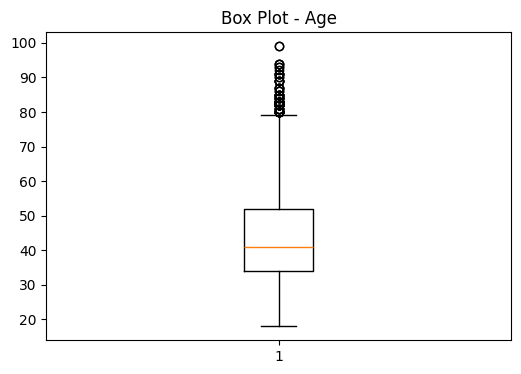

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['Age'])
plt.title("Box Plot - Age")
plt.show()

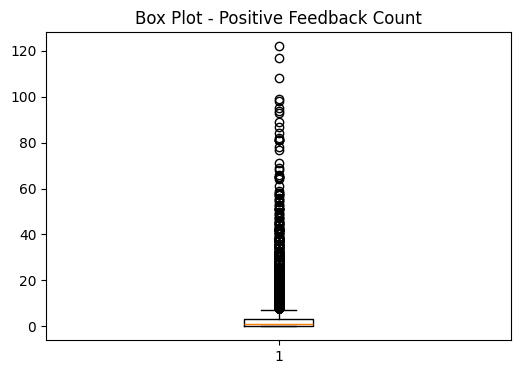

In [18]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Positive Feedback Count'])
plt.title("Box Plot - Positive Feedback Count")
plt.show()

In [21]:
# it covert the data between 0 to 1
# when larger column can have different ranges so it can dominates
# formula
# scaled values = current value - minimum values / maximum - minimum

In [23]:
# We scaled Age because it's a numerical feature.
# We want all numerical features to have a similar scale so that machine learning algorithms treat them fairly instead of giving more importance to features with larger numeric values.

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age_MinMax', 'Feedback_MinMax']] = scaler.fit_transform(
    df[['Age', 'Positive Feedback Count']]
)

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Age_MinMax,Feedback_MinMax
0,0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,0.185185,0.000000
1,1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,0.197531,0.032787
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,0.518519,0.000000
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,0.395062,0.000000
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,0.358025,0.049180


In [28]:
# comparing previous and now
# comparing because have to check its benn applied proper or not

In [29]:
df[['Age',
    'Age_MinMax',
    'Positive Feedback Count',
    'Feedback_MinMax']].head(10)

,Age,Age_MinMax,Positive Feedback Count,Feedback_MinMax
0,33,0.185185,0,0.000000
1,34,0.197531,4,0.032787
2,60,0.518519,0,0.000000
3,50,0.395062,0,0.000000
4,47,0.358025,6,0.049180
5,49,0.382716,4,0.032787
6,39,0.259259,1,0.008197
7,39,0.259259,4,0.032787
8,24,0.074074,0,0.000000
9,34,0.197531,0,0.000000


In [ ]:
# we are creating list of cat column so we can work together on categorical column

In [32]:
cat_cols = ['Division Name', 'Department Name', 'Class Name']

for col in cat_cols:
    print("="*50)
    print("Column :", col)
    print("Number of Unique Values :", df[col].nunique())
    print(df[col].unique())

Column : Division Name
Number of Unique Values : 3
['Initmates' 'General' 'General Petite']
Column : Department Name
Number of Unique Values : 6
['Intimate' 'Dresses' 'Bottoms' 'Tops' 'Jackets' 'Trend']
Column : Class Name
Number of Unique Values : 20
['Intimates' 'Dresses' 'Pants' 'Blouses' 'Knits' 'Outerwear' 'Lounge'
 'Sweaters' 'Skirts' 'Fine gauge' 'Sleep' 'Jackets' 'Swim' 'Trend' 'Jeans'
 'Legwear' 'Shorts' 'Layering' 'Casual bottoms' 'Chemises']


In [33]:
for col in cat_cols:
    print("="*50)
    print("Column :", col)
    print(df[col].value_counts())

Column : Division Name
Division Name
General           13864
General Petite     8120
Initmates          1502
Name: count, dtype: int64
Column : Department Name
Department Name
Tops        10482
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Name: count, dtype: int64
Column : Class Name
Class Name
Dresses           6333
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
Casual bottoms       2
Chemises             1
Name: count, dtype: int64


In [35]:
# We loop through each categorical column, find its most frequent category (mode), and replace all missing values with that category so
# the dataset has no missing categorical values.

In [36]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_890/1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [37]:
df[cat_cols].isnull().sum()

,0
Division Name,0
Department Name,0
Class Name,0


In [38]:
# label encoder

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Division Name_Label'] = le.fit_transform(df['Division Name'])

df[['Division Name', 'Division Name_Label']].head(10)

,Division Name,Division Name_Label
0,Initmates,2
1,General,0
2,General,0
3,General Petite,1
4,General,0
5,General,0
6,General Petite,1
7,General Petite,1
8,General,0
9,General,0


In [40]:
le = LabelEncoder()

df['Department Name_Label'] = le.fit_transform(df['Department Name'])

df[['Department Name', 'Department Name_Label']].head(10)

,Department Name,Department Name_Label
0,Intimate,2
1,Dresses,1
2,Dresses,1
3,Bottoms,0
4,Tops,4
5,Dresses,1
6,Tops,4
7,Tops,4
8,Dresses,1
9,Dresses,1


In [41]:
le = LabelEncoder()

df['Class Name_Label'] = le.fit_transform(df['Class Name'])

df[['Class Name', 'Class Name_Label']].head(10)

,Class Name,Class Name_Label
0,Intimates,5
1,Dresses,3
2,Dresses,3
3,Pants,13
4,Blouses,0
5,Dresses,3
6,Knits,8
7,Knits,8
8,Dresses,3
9,Dresses,3


In [42]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'Blouses': np.int64(0), 'Casual bottoms': np.int64(1), 'Chemises': np.int64(2), 'Dresses': np.int64(3), 'Fine gauge': np.int64(4), 'Intimates': np.int64(5), 'Jackets': np.int64(6), 'Jeans': np.int64(7), 'Knits': np.int64(8), 'Layering': np.int64(9), 'Legwear': np.int64(10), 'Lounge': np.int64(11), 'Outerwear': np.int64(12), 'Pants': np.int64(13), 'Shorts': np.int64(14), 'Skirts': np.int64(15), 'Sleep': np.int64(16), 'Sweaters': np.int64(17), 'Swim': np.int64(18), 'Trend': np.int64(19)}


In [43]:
one_hot = pd.get_dummies(
    df[cat_cols],
    dtype=int
)

one_hot.head()

,Division Name_General,Division Name_General Petite,Division Name_Initmates,Department Name_Bottoms,Department Name_Dresses,Department Name_Intimate,Department Name_Jackets,Department Name_Tops,Department Name_Trend,Class Name_Blouses,...,Class Name_Legwear,Class Name_Lounge,Class Name_Outerwear,Class Name_Pants,Class Name_Shorts,Class Name_Skirts,Class Name_Sleep,Class Name_Sweaters,Class Name_Swim,Class Name_Trend
0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [44]:
one_hot.shape

(23486, 29)

In [47]:
# adding one hot in cat

In [51]:
df = pd.concat([df, one_hot], axis=1)

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Age_MinMax,Feedback_MinMax,...,Class Name_Legwear,Class Name_Lounge,Class Name_Outerwear,Class Name_Pants,Class Name_Shorts,Class Name_Skirts,Class Name_Sleep,Class Name_Sweaters,Class Name_Swim,Class Name_Trend
0,0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,0.185185,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,0.197531,0.032787,...,0,0,0,0,0,0,0,0,0,0
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,0.518519,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,0.395062,0.000000,...,0,0,0,1,0,0,0,0,0,0
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,0.358025,0.049180,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 100 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    23486 non-null  int64  
 1   Clothing ID                   23486 non-null  int64  
 2   Age                           23486 non-null  int64  
 3   Title                         23486 non-null  object 
 4   Review Text                   23486 non-null  object 
 5   Rating                        23486 non-null  int64  
 6   Recommended IND               23486 non-null  int64  
 7   Positive Feedback Count       23486 non-null  int64  
 8   Age_MinMax                    23486 non-null  float64
 9   Feedback_MinMax               23486 non-null  float64
 10  Division Name_Label           23486 non-null  int64  
 11  Department Name_Label         23486 non-null  int64  
 12  Class Name_Label              23486 non-null  int64  
 13  

In [55]:
df['Review Text'] = df['Review Text'].str.lower()

In [56]:
import re

In [57]:
def remove_numbers(text):
    return re.sub(r'\d+', '', str(text))

df['Review Text'] = df['Review Text'].apply(remove_numbers)

In [58]:
import nltk

In [59]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [60]:
from nltk.tokenize import word_tokenize

df['Tokens'] = df['Review Text'].apply(word_tokenize)

df[['Review Text','Tokens']].head()

,Review Text,Tokens
0,absolutely wonderful - silky and sexy and comf...,"[absolutely, wonderful, -, silky, and, sexy, a..."
1,love this dress! it's sooo pretty. i happene...,"[love, this, dress, !, it, 's, sooo, pretty, ...."
2,i had such high hopes for this dress and reall...,"[i, had, such, high, hopes, for, this, dress, ..."
3,"i love, love, love this jumpsuit. it's fun, fl...","[i, love, ,, love, ,, love, this, jumpsuit, .,..."
4,this shirt is very flattering to all due to th...,"[this, shirt, is, very, flattering, to, all, d..."


In [61]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [62]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['Tokens'] = df['Tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [63]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df['Stemmed'] = df['Tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

df[['Tokens','Stemmed']].head()

,Tokens,Stemmed
0,"[absolutely, wonderful, -, silky, sexy, comfor...","[absolut, wonder, -, silki, sexi, comfort]"
1,"[love, dress, !, 's, sooo, pretty, ., happened...","[love, dress, !, 's, sooo, pretti, ., happen, ..."
2,"[high, hopes, dress, really, wanted, work, ., ...","[high, hope, dress, realli, want, work, ., ini..."
3,"[love, ,, love, ,, love, jumpsuit, ., 's, fun,...","[love, ,, love, ,, love, jumpsuit, ., 's, fun,..."
4,"[shirt, flattering, due, adjustable, front, ti...","[shirt, flatter, due, adjust, front, tie, ., p..."


In [67]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [68]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Lemmatized'] = df['Tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[['Tokens','Lemmatized']].head()

,Tokens,Lemmatized
0,"[absolutely, wonderful, -, silky, sexy, comfor...","[absolutely, wonderful, -, silky, sexy, comfor..."
1,"[love, dress, !, 's, sooo, pretty, ., happened...","[love, dress, !, 's, sooo, pretty, ., happened..."
2,"[high, hopes, dress, really, wanted, work, ., ...","[high, hope, dress, really, wanted, work, ., i..."
3,"[love, ,, love, ,, love, jumpsuit, ., 's, fun,...","[love, ,, love, ,, love, jumpsuit, ., 's, fun,..."
4,"[shirt, flattering, due, adjustable, front, ti...","[shirt, flattering, due, adjustable, front, ti..."


In [71]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Lemmatized'] = df['Tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[['Tokens','Lemmatized']].head()

,Tokens,Lemmatized
0,"[absolutely, wonderful, -, silky, sexy, comfor...","[absolutely, wonderful, -, silky, sexy, comfor..."
1,"[love, dress, !, 's, sooo, pretty, ., happened...","[love, dress, !, 's, sooo, pretty, ., happened..."
2,"[high, hopes, dress, really, wanted, work, ., ...","[high, hope, dress, really, wanted, work, ., i..."
3,"[love, ,, love, ,, love, jumpsuit, ., 's, fun,...","[love, ,, love, ,, love, jumpsuit, ., 's, fun,..."
4,"[shirt, flattering, due, adjustable, front, ti...","[shirt, flattering, due, adjustable, front, ti..."


In [72]:
df['Clean_Text'] = df['Lemmatized'].apply(lambda words: " ".join(words))

df[['Review Text','Clean_Text']].head()

,Review Text,Clean_Text
0,absolutely wonderful - silky and sexy and comf...,absolutely wonderful - silky sexy comfortable
1,love this dress! it's sooo pretty. i happene...,love dress ! 's sooo pretty . happened find st...
2,i had such high hopes for this dress and reall...,high hope dress really wanted work . initially...
3,"i love, love, love this jumpsuit. it's fun, fl...","love , love , love jumpsuit . 's fun , flirty ..."
4,this shirt is very flattering to all due to th...,shirt flattering due adjustable front tie . pe...


In [73]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

bow = cv.fit_transform(df['Clean_Text'])

bow_df = pd.DataFrame(
    bow.toarray(),
    columns=cv.get_feature_names_out()
)

bow_df.head()

,______,_______,________,_________,__________,___________,____________,_____________,______________,_______________,...,zippered,zippie,zipping,zombie,zone,zoolander,zoom,zooming,zuma,ã¼ber
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
print(cv.get_feature_names_out())

['______' '_______' '________' ... 'zooming' 'zuma' 'ã¼ber']


In [75]:
bow_df.shape

(23486, 12392)

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(df['Clean_Text'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,______,_______,________,_________,__________,___________,____________,_____________,______________,_______________,...,zippered,zippie,zipping,zombie,zone,zoolander,zoom,zooming,zuma,ã¼ber
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
print(tfidf.get_feature_names_out())

['______' '_______' '________' ... 'zooming' 'zuma' 'ã¼ber']


In [78]:
tfidf_df.shape

(23486, 12392)

In [79]:
final_df = df.drop(
    columns=[
        'Title',
        'Review Text',
        'Tokens',
        'Stemmed',
        'Lemmatized',
        'Clean_Text'
    ],
    errors='ignore'
)

In [80]:
final_df = pd.concat(
    [final_df.reset_index(drop=True),
     tfidf_df.reset_index(drop=True)],
    axis=1
)

In [81]:
final_df.head()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Age_MinMax,Feedback_MinMax,Division Name_Label,Department Name_Label,...,zippered,zippie,zipping,zombie,zone,zoolander,zoom,zooming,zuma,ã¼ber
0,0,767,33,4,1,0,0.185185,0.000000,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1080,34,5,1,4,0.197531,0.032787,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1077,60,3,0,0,0.518519,0.000000,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,1049,50,5,1,0,0.395062,0.000000,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,847,47,5,1,6,0.358025,0.049180,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
